# How to express the Arrhenius-like Tackley Viscosity using the diffusion creep constitutive relationship

In [7]:
using Plots 

In [8]:
n       =   100
T       =   LinRange(0,1,n)
η_T     =   zeros(n)

η₀ = 1; T_O = 1; T_η = 1; E_A = log(1e5^2)

@. η_T = η₀*exp(E_A/(T+T_O)-E_A/(T_η+T_O));

# p = plot(T,log10.(η_T),
#             xlabel="T",ylabel="log10(η)",
#             xlim=(0,1),ylim=(0,5),label="")


100-element Vector{Float64}:
 100000.00000000001
  79432.82347242796
  63384.08101544694
  50802.18046913016
  40893.14245619846
  33054.513475732405
  26826.95795279733
  21858.615034246744
  17878.721057334144
  14677.992676220729
      ⋮
      1.6237767391887237
      1.5249165339518134
      1.4330125702369632
      1.3475152186759225
      1.2679227183627855
      1.1937766417144353
      1.1246578221198205
      1.0601826939066563
      1.0

# Arrhenius Viscosity using Diffusion Creep

### Arrhenius Viscosity (e.g., Tackley, 2000)

$\begin{equation}
\eta_T = \eta_0 exp \left(\frac{E_A}{T+T_O} - \frac{E_A}{T_\eta + T_O}\right)
\end{equation}$

$\begin{equation}\begin{gather*}
& T_O = 1 \\
& T_\eta = 1
\end{gather*}\end{equation}$

$T_O$ ensures that the Arrhenius law is applied to absolute temperature $T_{abs}=\Delta{T}\left(T+T_O\right)$ and $T_{\eta}$ is the reference temperature at which $\eta = \eta_0$. 

$\begin{equation}
\eta_T = \eta_0 exp \left(\frac{E_A}{T+1} - \frac{E_A}{2}\right)
\end{equation}$

### Expressing the Arrhenius law with the diffusion creep equation

**diffusion creep constitutive relation**

$\begin{equation}
\dot{\varepsilon}_{II} = A_d \tau_{II} C_{OH}^r d^{-p} exp\left(-\frac{E_d+PV_d}{RT}\right)
\end{equation}$

**Diffusion creep viscosity**

$\begin{equation}
\eta\left(T,P\right)=\frac{d^p}{2A_dC_{OH}^r}exp\left(\frac{E_d+PV_d}{RT}\right)
\end{equation}$

**Simplification**

$\begin{equation}
\eta\left(T\right)=\frac{1}{2A_d}exp\left(\frac{E_d}{RT}\right)
\end{equation}$

The Arrhenius law from Tackley is shifted due to a choice of a reference viscosity $\eta_0$ at a certain reference temperature $T_\eta$. One can adjust equation (6) via this reference viscosity through

$\begin{equation}
\eta\left(T_{\eta,abs}\right) = \eta_0,
\end{equation}$

where 

$\begin{equation}
T_{\eta,abs} = \Delta T\left(T_{\eta}+T_O\right).
\end{equation}$

Which results in: 

$\begin{equation}
\eta_0 = \frac{1}{2A_d}exp\left(\frac{E_d}{RT_{\eta,abs}}\right),
\end{equation}$

and solving for $A_d$: 

$\begin{equation}
A_d = \frac{1}{2\eta_0}exp\left(\frac{E_d}{RT_{\eta,abs}}\right).
\end{equation}$

The temperature dependent diffusion creep viscosity is then defined by:  

$\begin{equation}
\eta\left(T\right) = \eta_0 exp\left(- \frac{E_d}{RT_{\eta,abs}}\right)exp\left(\frac{E_d}{RT}\right),
\end{equation}$

or in a similar form as in the Arrhenius formulation from Tackley (2000)

$\begin{equation}
\eta\left(T\right) = \eta_0 exp\left[\frac{E_d}{R}\left(\frac{1}{T}-\frac{1}{T_{\eta,abs}}\right)\right]. 
\end{equation}$

Equation (12) is a shifted diffusion creep viscosity formulation, that resembles the form of the viscosity equation as defined by Tackley. 

---------

A straight forward way to defined the parameters for the diffusion creep equation that represent the behavior of the Arrhenius like viscosity from Equation (1) is to express the Tackley law in dimensional forms. 

Let the dimensional temperature be

$\begin{equation}
T_{abs} = \Delta T\left(T+T_O\right),
\end{equation}$

where $\Delta T$ is the temperature scale and $T_O$ and offset temperature. Then

$\begin{equation}
\frac{E_A}{T+T_O}=\frac{E_A\Delta{T}}{T_{abs}}.
\end{equation}$

Therefore, Tackley's dimensional Arrhenius law becomes: 

$\begin{equation}
\eta\left(T_{abs}\right) = \eta_0 exp\left[E_A\Delta{T}\left(\frac{1}{T_{abs}}-\frac{1}{T_{\eta,abs}}\right)\right].
\end{equation}$

Comparing Equations (15) and (11) leads to: 

$\begin{equation}
\frac{E_d}{R}=E_A\Delta{T} => E_d=E_AR\Delta{T}
\end{equation}$

---

So the dimensional diffusion equation which represent the behavior of the Arrhenius like formulation from Tackley can be expressed via: 

$\begin{equation}
\eta\left(T\right) = \eta_0 exp\left(- \frac{E_d}{RT_\eta}\right)exp\left(\frac{E_d}{RT_{abs}}\right)
\end{equation}$

with $\eta_0$ as a reference viscosity, 

$E_d = E_AR\Delta{T}$,

$T_{abs} = \Delta{T}\left(\theta+T_O\right)$, and

$T_{\eta} = \Delta{T}\left(\theta_{\eta} + T_O\right)$,

where $\theta$ is the non-dimensional temperature and $T_O$ the non-dimensional offset temperature. 

E_d = 248868.00202098244
(ηt₀, 1 / ηt₀) = (1.0264086261000018e18, 9.74270845520516e-19)
(η_diff[1], η_diff[end]) = (1.0264086260999986e28, 1.0264086261000001e23)


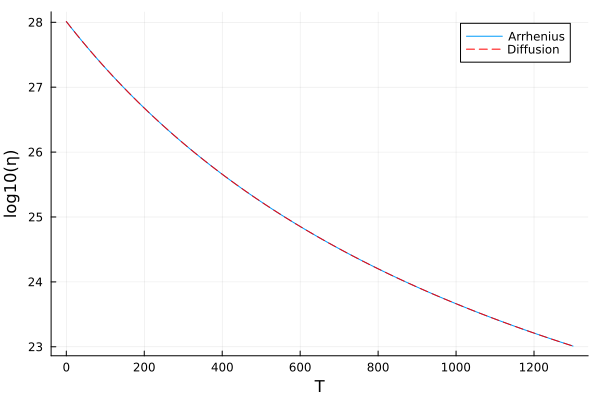

In [ ]:
# Scaling values 

η_sc    =   1.0264086261000001e23    # [Pas]
ΔT      =   1300    # [K]
R_G     =   8.314   # [J/mol/K]

# Calculate viscosity profile using diffusion creep equation

η_diff =   zeros(n)

E_d     =   E_A*R_G*ΔT
@show E_d

ηt₀     =   η₀*η_sc * exp(-(E_d)/(R_G*(ΔT*(T_η+T_O))))
@show ηt₀, 1/ηt₀

@. η_diff   =  ηt₀ * exp((E_d)/(R_G*((T+T_O)*ΔT)))

@show η_diff[1], η_diff[end]

q = plot(T.*ΔT,log10.(η_T.*η_sc),label="Arrhenius")

plot!(q,T.*ΔT,log10.(η_diff),linestyle=:dash,color=:red,
            xlabel="T",ylabel="log10(η)",label="Diffusion")
display(q)